# Bai 2: Phan loai Spam - Encoding ket hop N-gram + TF-IDF

Giong Bai 1 nhung phan **encoding** dung **N-gram + TF-IDF** (`TfidfVectorizer`).
Sau do **so sanh** voi Bai 1 (N-gram dem tan suat - `CountVectorizer`) va **giai thich**.

Dataset: `spam_or_not_spam.csv` (cot `email`, `label`; 0 = not spam, 1 = spam).

## Cell 1 - Import thu vien

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

CONFIG = {
    "csv_path": "spam_or_not_spam.csv",
    "test_size": 0.2,
    "random_state": 42,
    "ngram_range": (1, 2),
    "min_df": 2,
}
print("Da import xong thu vien.")

Da import xong thu vien.


## Cell 2 - Get data (doc du lieu)

In [2]:
def load_data(csv_path):
    """Doc file CSV -> DataFrame gom 2 cot: email, label."""
    return pd.read_csv(csv_path)

df = load_data(CONFIG["csv_path"])
print("Kich thuoc:", df.shape)
print(df["label"].value_counts())
df.head()

Kich thuoc: (3000, 2)
label
0    2500
1     500
Name: count, dtype: int64


,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


## Cell 3 - Xu ly (lam sach & tien xu ly)

In [3]:
def clean_text(text):
    """Lam sach 1 email: viet thuong, chi giu chu cai, gom khoang trang."""
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def preprocess(df):
    """Bo dong NaN/rong va them cot 'clean'."""
    df = df.dropna(subset=["email"]).copy()
    df["clean"] = df["email"].apply(clean_text)
    df = df[df["clean"].str.len() > 0]
    return df

df = preprocess(df)
print("Sau lam sach:", df.shape[0], "email")

Sau lam sach:

 2997 email


## Cell 4 - Class & ham (chon kieu encoding count / tfidf)

In [4]:
class SpamClassifier:
    """Chon 1 trong 2 kieu encoding:
       - 'count': N-gram dem tan suat (Bai 1)
       - 'tfidf': N-gram + TF-IDF (Bai 2)
    """

    def __init__(self, encoding="tfidf", ngram_range=(1, 2), min_df=2):
        self.encoding = encoding
        if encoding == "count":
            self.vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
        elif encoding == "tfidf":
            self.vectorizer = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df)
        else:
            raise ValueError("encoding phai la 'count' hoac 'tfidf'")
        self.model = MultinomialNB()  # dung chung 1 mo hinh de so sanh cong bang

    def fit(self, texts, labels):
        X = self.vectorizer.fit_transform(texts)
        self.model.fit(X, labels)
        return self

    def predict(self, texts):
        return self.model.predict(self.vectorizer.transform(texts))

print("Da dinh nghia class SpamClassifier.")

Da dinh nghia class SpamClassifier.


## Cell 5 - Utils (danh gia & ve bieu do)

In [5]:
def evaluate(y_true, y_pred, show_report=True):
    """Tinh accuracy va in bao cao chi tiet."""
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")
    if show_report:
        print(classification_report(y_true, y_pred, target_names=["not spam", "spam"]))
    return acc

def plot_compare(acc_count, acc_tfidf):
    """Bieu do cot so sanh accuracy 2 kieu encoding."""
    fig, ax = plt.subplots(figsize=(4.5, 4))
    names = ["N-gram (Count)\nBai 1", "N-gram + TF-IDF\nBai 2"]
    vals = [acc_count, acc_tfidf]
    ax.bar(names, vals, color=["#4c72b0", "#55a868"])
    ax.set_ylim(0.8, 1.0); ax.set_ylabel("Accuracy")
    ax.set_title("So sanh 2 kieu encoding (cung Naive Bayes)")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.004, f"{v:.4f}", ha="center")
    plt.tight_layout(); return fig

print("Da dinh nghia ham utils.")

Da dinh nghia ham utils.


## Cell 6 - Main (so sanh 2 kieu encoding theo de)

In [6]:
# Chia train/test dung chung cho ca 2 kieu encoding -> so sanh cong bang
X_train, X_test, y_train, y_test = train_test_split(
    df["clean"], df["label"],
    test_size=CONFIG["test_size"], random_state=CONFIG["random_state"],
    stratify=df["label"],
)

# Cach 1: N-gram dem tan suat (Bai 1)
print("=== Cach 1: N-gram (Count) + Naive Bayes ===")
clf_count = SpamClassifier("count", CONFIG["ngram_range"], CONFIG["min_df"]).fit(X_train, y_train)
acc_count = evaluate(y_test, clf_count.predict(X_test))

# Cach 2: N-gram + TF-IDF (Bai 2)
print("=== Cach 2: N-gram + TF-IDF + Naive Bayes ===")
clf_tfidf = SpamClassifier("tfidf", CONFIG["ngram_range"], CONFIG["min_df"]).fit(X_train, y_train)
acc_tfidf = evaluate(y_test, clf_tfidf.predict(X_test))

# Kiem chung: TF-IDF di voi Logistic Regression (mo hinh tuyen tinh)
_tv = TfidfVectorizer(ngram_range=CONFIG["ngram_range"], min_df=CONFIG["min_df"])
_Xtr, _Xte = _tv.fit_transform(X_train), _tv.transform(X_test)
_lr = LogisticRegression(max_iter=1000, class_weight="balanced").fit(_Xtr, y_train)
acc_tfidf_lr = accuracy_score(y_test, _lr.predict(_Xte))
print(f"(Kiem chung) TF-IDF + Logistic Regression: {acc_tfidf_lr:.4f}")

=== Cach 1: N-gram (Count) + Naive Bayes ===


Accuracy: 0.9933
              precision    recall  f1-score   support

    not spam       0.99      1.00      1.00       501
        spam       1.00      0.96      0.98        99

    accuracy                           0.99       600
   macro avg       1.00      0.98      0.99       600
weighted avg       0.99      0.99      0.99       600

=== Cach 2: N-gram + TF-IDF + Naive Bayes ===


Accuracy: 0.9033
              precision    recall  f1-score   support

    not spam       0.90      1.00      0.95       501
        spam       1.00      0.41      0.59        99

    accuracy                           0.90       600
   macro avg       0.95      0.71      0.77       600
weighted avg       0.91      0.90      0.89       600



(Kiem chung) TF-IDF + Logistic Regression: 0.9917


## Cell 7 - Show bieu do & giai thich

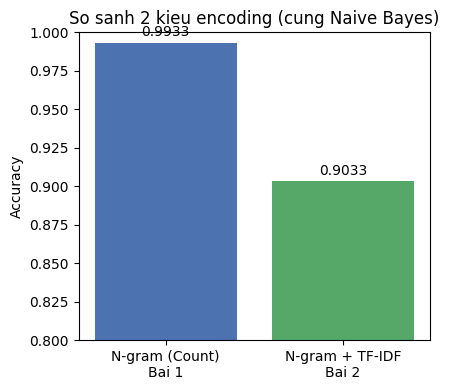

=== SO SANH ===
N-gram (Count)  + NB           : 0.9933
N-gram + TF-IDF + NB           : 0.9033
N-gram + TF-IDF + LogisticReg  : 0.9917


In [7]:
plot_compare(acc_count, acc_tfidf)
plt.show()

print("=== SO SANH ===")
print(f"N-gram (Count)  + NB           : {acc_count:.4f}")
print(f"N-gram + TF-IDF + NB           : {acc_tfidf:.4f}")
print(f"N-gram + TF-IDF + LogisticReg  : {acc_tfidf_lr:.4f}")

## Giai thich ket qua

**1. Y nghia 2 kieu encoding**
- `CountVectorizer` (Bai 1): chi **dem** so lan xuat hien moi n-gram (so nguyen).
- `TfidfVectorizer` (Bai 2): so dem do **nhan trong so IDF** -> ha thap tu xuat hien o hau het email, de cao tu hiem mang tinh phan biet (free, money, click...). Vector duoc chuan hoa L2 (so thuc).

**2. Vi sao tren tap nay TF-IDF + Naive Bayes lai THAP hon (~0.90 < 0.99, recall spam ~0.41)?**
- `MultinomialNB` von duoc thiet ke cho dac trung dang **dem**. TF-IDF bien dac trung thanh so thuc da chuan hoa, lam **sai lech gia dinh phan phoi** cua NB.
- Du lieu **mat can bang** (2500 not-spam / 500 spam). TF-IDF lam nhat trong so cac tu, cong voi prior thien ve lop da so -> NB "ngai" du doan spam, **bo sot hon mot nua so spam**.

**3. Ket luan**
- TF-IDF **khong phai luc nao cung tot hon**. Cap encoding - mo hinh phai phu hop nhau.
- Voi NB tren du lieu dang dem & mat can bang, **CountVectorizer phu hop hon**.
- TF-IDF phat huy the manh khi di kem **mo hinh tuyen tinh**: o tren TF-IDF + Logistic Regression dat lai ~0.99, ngang voi Count + NB.